In [8]:
## TUGAS TABEL PERBANDINGAN

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
# SVM Linear
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)
acc_svm_linear = accuracy_score(y_test, svm_linear.predict(X_test_scaled))

# SVM RBF
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)
acc_svm_rbf = accuracy_score(y_test, svm_rbf.predict(X_test_scaled))


print("| Model       | Accuracy |")
print("|-------------|----------|")
print(f"| KNN (k=5)   | {acc_knn:.4f}   |")
print(f"| SVM Linear  | {acc_svm_linear:.4f}   |")
print(f"| SVM RBF     | {acc_svm_rbf:.4f}   |")

| Model       | Accuracy |
|-------------|----------|
| KNN (k=5)   | 0.9035   |
| SVM Linear  | 0.9035   |
| SVM RBF     | 0.9211   |


In [9]:
# TUGAS INDIVIDU

# KNN dengan scaling
knn_with_scale = KNeighborsClassifier(n_neighbors=5)
knn_with_scale.fit(X_train_scaled, y_train)
pred_with_scale = knn_with_scale.predict(X_test_scaled)
acc_with_scale = accuracy_score(y_test, pred_with_scale)

# KNN tanpa scaling
knn_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_no_scale.fit(X_train, y_train) 
pred_no_scale = knn_no_scale.predict(X_test)
acc_no_scale = accuracy_score(y_test, pred_no_scale)

# Tampilkan hasil
print("\n PERBANDINGAN:")
print("-" * 50)
print(f"{'Kondisi':<30} {'Akurasi'}")
print("-" * 50)
print(f"{'KNN dengan Scaling':<30} {acc_with_scale*100:.2f}%")
print(f"{'KNN tanpa Scaling':<30} {acc_no_scale*100:.2f}%")
print("-" * 50)
print(f"{'Selisih':<30} {(acc_with_scale - acc_no_scale)*100:.2f}%")


 PERBANDINGAN:
--------------------------------------------------
Kondisi                        Akurasi
--------------------------------------------------
KNN dengan Scaling             90.35%
KNN tanpa Scaling              90.35%
--------------------------------------------------
Selisih                        0.00%


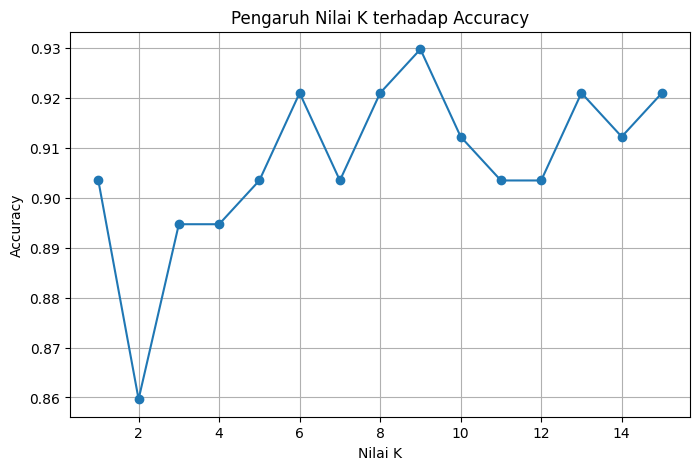

In [13]:
# Uji Nilai K Hingga 15

k_values = range(1, 16)

accs = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accs.append(
        accuracy_score(y_test, y_pred)
    )

plt.figure(figsize=(8,5))
plt.plot(k_values, accs, marker='o')

plt.xlabel("Nilai K")
plt.ylabel("Accuracy")
plt.title("Pengaruh Nilai K terhadap Accuracy")
plt.grid(True)

plt.show()

In [14]:
# Mengubah parameter SVM
for c in [0.1, 1, 10]:
    svm = SVC(kernel='rbf', C=c)
    svm.fit(X_train_scaled, y_train)
    print(f"C={c}: {accuracy_score(y_test, svm.predict(X_test_scaled))}")

C=0.1: 0.9035087719298246
C=1: 0.9210526315789473
C=10: 0.9122807017543859


In [15]:

svm_scale = SVC(kernel='rbf', gamma='scale')
svm_scale.fit(X_train_scaled, y_train)
acc_scale = accuracy_score(y_test, svm_scale.predict(X_test_scaled))

svm_auto = SVC(kernel='rbf', gamma='auto')
svm_auto.fit(X_train_scaled, y_train)
acc_auto = accuracy_score(y_test, svm_auto.predict(X_test_scaled))

# Tampilkan perbandingan
print("| gamma setting | Accuracy |")
print("|---------------|----------|")
print(f"| 'scale'       | {acc_scale:.4f}   |")
print(f"| 'auto'        | {acc_auto:.4f}   |")

| gamma setting | Accuracy |
|---------------|----------|
| 'scale'       | 0.9211   |
| 'auto'        | 0.9211   |


In [16]:
#5 fold cross validation
from sklearn.model_selection import cross_val_score

models = {
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM Linear": SVC(kernel='linear'),
    "SVM RBF": SVC(kernel='rbf')
}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}")

KNN (k=5): mean=0.8747, std=0.0345
SVM Linear: mean=0.8835, std=0.0283
SVM RBF: mean=0.8989, std=0.0364
